In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
ticker = "AAPL"

In [3]:
stock_data = yf.download(ticker, start="2016-01-01", end="2024-12-31", progress=False)

In [4]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-01-04,23.709103,23.713605,22.955183,23.092464,270597600
2016-01-05,23.114967,23.821627,23.047453,23.799122,223164000
2016-01-06,22.662615,23.038451,22.475824,22.631108,273829600
2016-01-07,21.706154,22.534341,21.701654,22.208018,324377600
2016-01-08,21.820927,22.304786,21.775917,22.178758,283192000


In [5]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100
2024-12-27,253.967361,257.057633,251.453425,256.193131,42355300
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500


In [6]:
stock_data.shape

(2263, 5)

In [7]:
stock_data.to_csv("apple_stock_data.csv")

In [8]:
stock_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2263 entries, 2016-01-04 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2263 non-null   float64
 1   (High, AAPL)    2263 non-null   float64
 2   (Low, AAPL)     2263 non-null   float64
 3   (Open, AAPL)    2263 non-null   float64
 4   (Volume, AAPL)  2263 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 106.1 KB


In [9]:
stock_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2263.000000,2263.000000,2263.000000,2263.000000,2.263000e+03
mean,101.064961,102.045294,99.969750,100.964352,1.070627e+08
std,64.653052,65.234583,63.978795,64.575943,5.825637e+07
min,20.565866,20.868645,20.367812,20.488471,2.323470e+07
25%,40.473148,40.799544,40.201621,40.453184,6.864935e+07
50%,88.312065,89.674847,87.689981,88.350784,9.398400e+07
75%,156.368080,159.004160,154.295979,156.741858,1.295468e+08
max,257.375580,258.448740,255.994420,256.550862,5.334788e+08


In [10]:
stock_data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

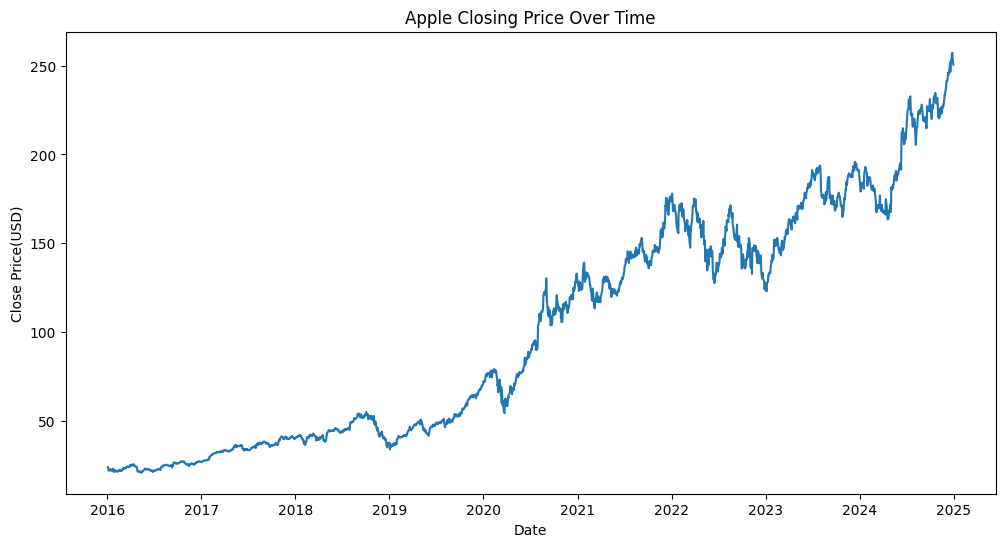

In [11]:
plt.figure(figsize=(12,6))

plt.plot(stock_data.index, stock_data['Close'])

plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price(USD)")

plt.show()

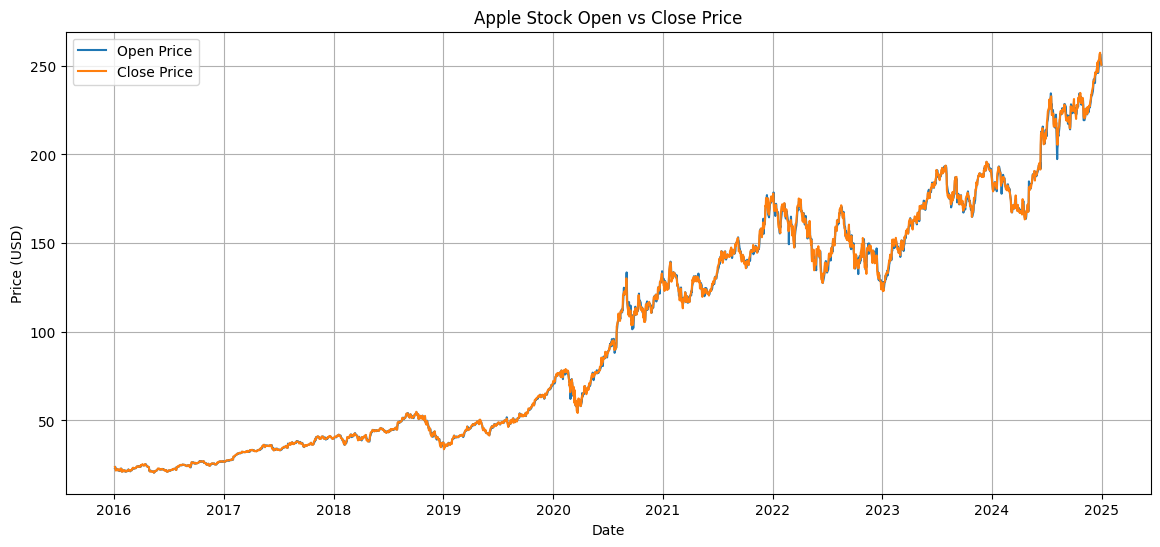

In [12]:

plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['Open'], label='Open Price')
plt.plot(stock_data.index, stock_data['Close'], label='Close Price')
plt.title('Apple Stock Open vs Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

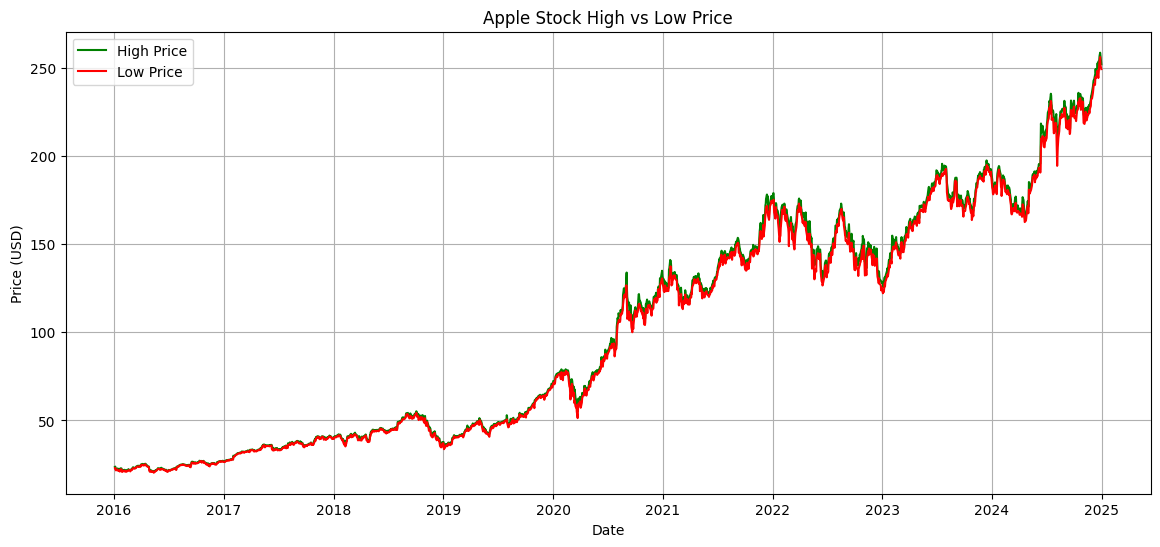

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['High'], label='High Price', color='green')
plt.plot(stock_data.index, stock_data['Low'], label='Low Price', color='red')
plt.title('Apple Stock High vs Low Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

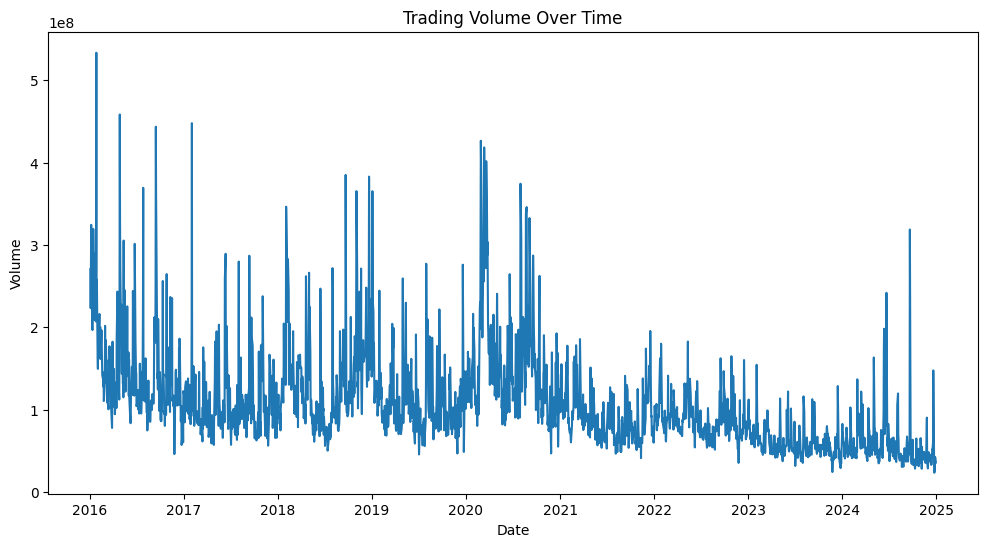

In [14]:
plt.figure(figsize=(12,6))

plt.plot(stock_data.index, stock_data['Volume'])

plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

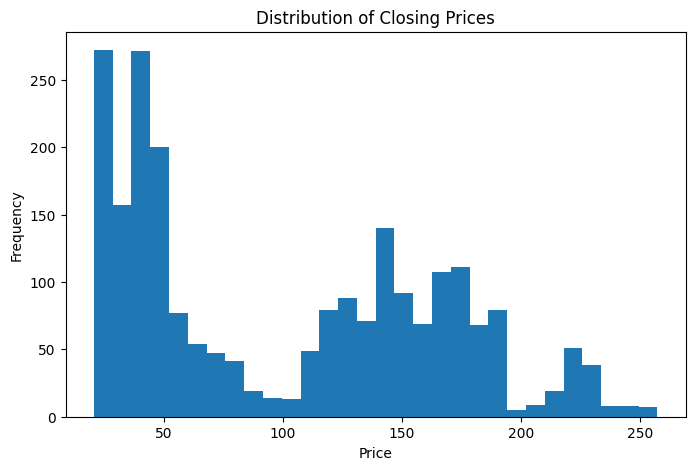

In [15]:
plt.figure(figsize=(8,5))

plt.hist(stock_data['Close'], bins=30)

plt.title("Distribution of Closing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

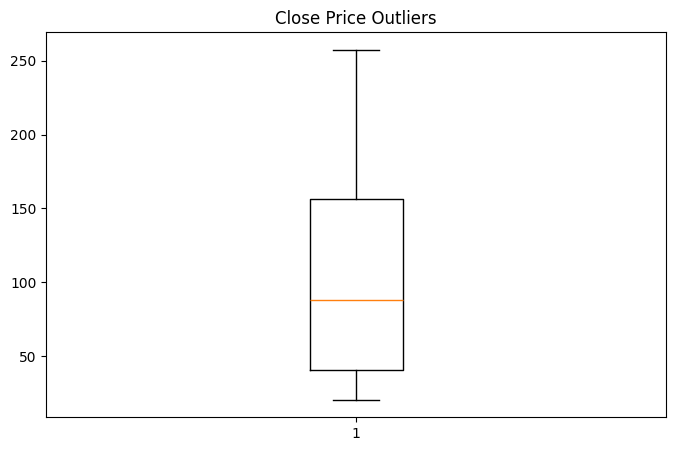

In [16]:
plt.figure(figsize=(8,5))

plt.boxplot(stock_data['Close'])

plt.title("Close Price Outliers")

plt.show()

In [17]:
stock_data['Daily_Return'] = (stock_data['Close'].pct_change())

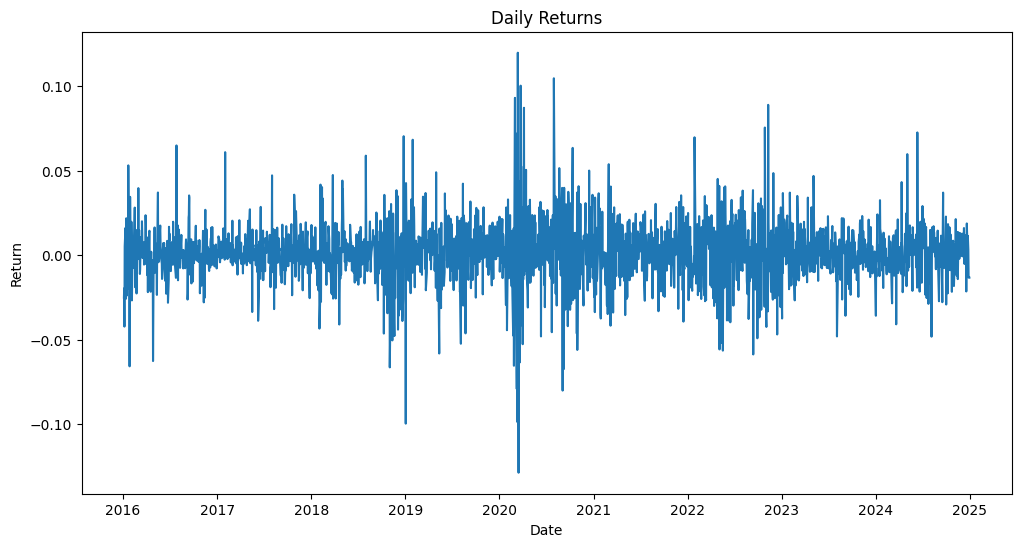

In [18]:
plt.figure(figsize=(12,6))

plt.plot(stock_data.index,stock_data['Daily_Return'])

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

In [19]:
stock_data['MA20'] = (stock_data['Close'].rolling(20).mean())

stock_data['MA50'] = (stock_data['Close'].rolling(50).mean())

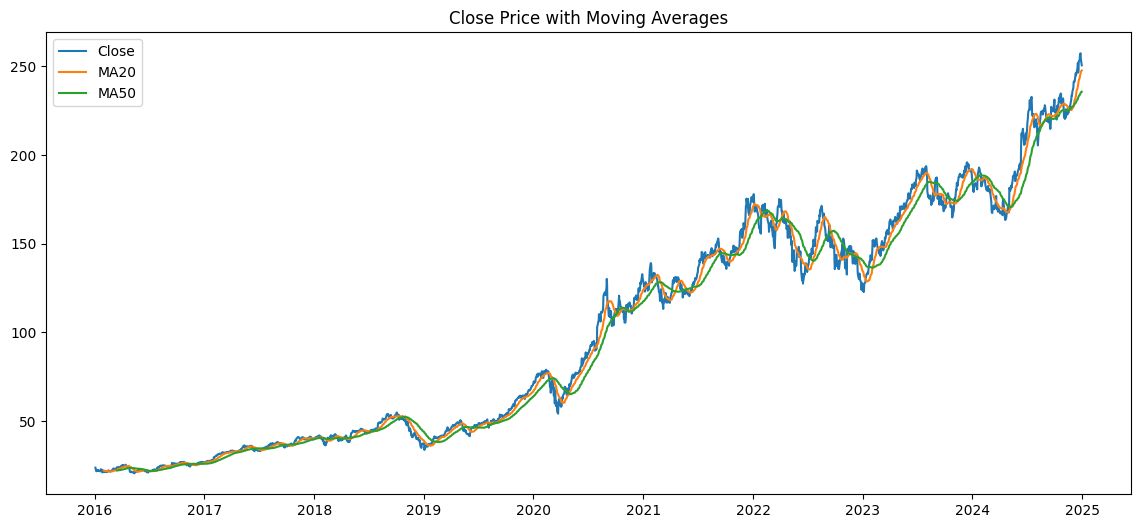

In [20]:
plt.figure(figsize=(14,6))

plt.plot(stock_data.index,stock_data['Close'],label='Close')

plt.plot(stock_data.index, stock_data['MA20'], label='MA20')

plt.plot(stock_data.index, stock_data['MA50'], label='MA50')

plt.legend()
plt.title("Close Price with Moving Averages")

plt.show()

In [21]:
correlation = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
print(correlation)

Price              Open      High       Low     Close    Volume
Ticker             AAPL      AAPL      AAPL      AAPL      AAPL
Price  Ticker                                                  
Open   AAPL    1.000000  0.999852  0.999849  0.999678 -0.501113
High   AAPL    0.999852  1.000000  0.999803  0.999850 -0.497247
Low    AAPL    0.999849  0.999803  1.000000  0.999849 -0.505437
Close  AAPL    0.999678  0.999850  0.999849  1.000000 -0.501589
Volume AAPL   -0.501113 -0.497247 -0.505437 -0.501589  1.000000


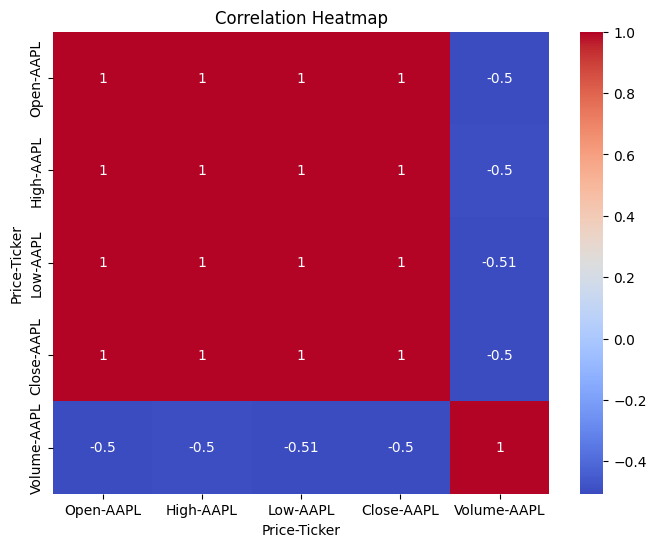

In [22]:

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [23]:
stock_data.isnull().sum()

Price         Ticker
Close         AAPL       0
High          AAPL       0
Low           AAPL       0
Open          AAPL       0
Volume        AAPL       0
Daily_Return             1
MA20                    19
MA50                    49
dtype: int64

In [24]:
stock_data['Target'] = stock_data['Close'].shift(-1)
stock_data.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800,0.003065,243.471445,233.786255,256.560852
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,244.729907,234.325892,257.375580
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920300,234.831203,253.967361
2024-12-27,253.967361,257.057633,251.453425,256.193131,42355300,-0.013242,246.946741,235.309442,250.598892
2024-12-30,250.598892,251.890642,249.158101,250.628701,35557500,-0.013263,247.685521,235.712966,NaN


In [25]:
stock_data = stock_data.dropna()
print("Final shape:", stock_data.shape)

Final shape: (2213, 9)


In [26]:
stock_data.tail()

Price,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2024-12-20,252.874374,253.381131,244.130238,246.465310,147495300,0.018816,242.209509,233.230406,253.649399
2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800,0.003065,243.471445,233.786255,256.560852
2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,244.729907,234.325892,257.375580
2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920300,234.831203,253.967361
2024-12-27,253.967361,257.057633,251.453425,256.193131,42355300,-0.013242,246.946741,235.309442,250.598892


In [27]:
stock_data.columns = stock_data.columns.get_level_values(0)

stock_data = stock_data.reset_index()


In [28]:
stock_data.head()

Price,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,2016-03-15,23.663523,23.799286,23.498343,23.523233,160270800,0.020093,22.500375,22.146492,23.978039
1,2016-03-16,23.978039,24.054970,23.665782,23.670309,153214000,0.013291,22.589186,22.151871,23.939575
2,2016-03-17,23.939575,24.091177,23.749506,23.876218,137682800,-0.001604,22.697118,22.168363,23.966730
3,2016-03-18,23.966730,24.097968,23.801553,24.061764,176820800,0.001134,22.808896,22.194445,23.964466
4,2016-03-21,23.964466,24.358179,23.790236,23.968991,142010800,-0.000094,22.911058,22.239612,24.147743


In [29]:
stock_data.to_csv('aapl_cleaned.csv')

In [30]:
stock_data

Price,Date,Close,High,Low,Open,Volume,Daily_Return,MA20,MA50,Target
0,2016-03-15,23.663523,23.799286,23.498343,23.523233,160270800,0.020093,22.500375,22.146492,23.978039
1,2016-03-16,23.978039,24.054970,23.665782,23.670309,153214000,0.013291,22.589186,22.151871,23.939575
2,2016-03-17,23.939575,24.091177,23.749506,23.876218,137682800,-0.001604,22.697118,22.168363,23.966730
3,2016-03-18,23.966730,24.097968,23.801553,24.061764,176820800,0.001134,22.808896,22.194445,23.964466
4,2016-03-21,23.964466,24.358179,23.790236,23.968991,142010800,-0.000094,22.911058,22.239612,24.147743
...,...,...,...,...,...,...,...,...,...,...
2208,2024-12-20,252.874374,253.381131,244.130238,246.465310,147495300,0.018816,242.209509,233.230406,253.649399
2209,2024-12-23,253.649399,254.026976,251.840946,253.152573,40858800,0.003065,243.471445,233.786255,256.560852
2210,2024-12-24,256.560852,256.570768,253.669307,253.868050,23234700,0.011478,244.729907,234.325892,257.375580
2211,2024-12-26,257.375580,258.448740,255.994420,256.550862,27237100,0.003176,245.920300,234.831203,253.967361
